¡Hola, Andrés!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-scientist. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
def compute_recovery(C, F, T):
    rec = (C * (F - T)) / (F * (C - T))
    rec = rec.replace([np.inf, -np.inf], np.nan)
    return (rec * 100).astype(float)

<div class="alert alert-block alert-success">
<b>Comentario revisor</b> <a class="tocSkip"></a><br>
    
    
Excelente trabajo con el calculo de la recuperación con los calculos propios, esto ayuda mucho a comprobar los resultados. Recuerda que estos pasos son muy relevantes cuando queremos hacer los análisis de información


Formula para calcular la recuperación 

In [3]:
def check_rougher_recovery_mae(df_train):
    need = ["rougher.output.concentrate_au",
            "rougher.input.feed_au",
            "rougher.output.tail_au",
            "rougher.output.recovery"]
    if not all(c in df_train.columns for c in need):
        print("No se puede verificar recovery (faltan columnas).")
        return None
    calc = compute_recovery(df_train[need[0]], df_train[need[1]], df_train[need[2]])
    mae  = (calc - df_train[need[3]]).abs().mean()
    print(f"[OK] MAE rougher.output.recovery (calc vs provisto): {mae:.6f}")
    return mae

Verificación de que el calculo sea correcto

In [4]:
def get_features(train, test, target_cols):
    num_train = [c for c in train.columns if pd.api.types.is_numeric_dtype(train[c])]
    num_test  = [c for c in test.columns  if pd.api.types.is_numeric_dtype(test[c])]
    common = sorted(set(num_train).intersection(num_test))
    feats = [c for c in common
             if not c.startswith("rougher.output.")
             and not c.startswith("final.output.")
             and c not in target_cols]
    return feats

In [5]:
def impute_median(train, test, features):
    med = train[features].median()
    train[features] = train[features].fillna(med)
    test[features]  = test[features].fillna(med)
    return train, test


In [6]:
def rmse(target_true, target_pred):
    return mean_squared_error(target_true, target_pred, squared=False)

In [7]:
def get_model(kind):
    if kind == "linreg": return LinearRegression()
    if kind == "tree":   return DecisionTreeRegressor(random_state=12345)
    if kind == "rf":     return RandomForestRegressor(n_estimators=300, random_state=12345, n_jobs=-1)
    raise ValueError("kind debe ser: 'linreg' | 'tree' | 'rf'")

In [8]:
rec_train=pd.read_csv('/datasets/gold_recovery_train.csv')
rec_test=pd.read_csv('/datasets/gold_recovery_test.csv')
rec_full=pd.read_csv('/datasets/gold_recovery_full.csv')

In [9]:
target_cols = ["rougher.output.recovery", "final.output.recovery"]
rec_train = rec_train.dropna(subset=target_cols).copy()
features = get_features(rec_train, rec_test, target_cols)
print(f"# de features: {len(features)}")
rec_train, rec_test = impute_median(rec_train, rec_test, features)

# de features: 52


In [10]:
n0 = rec_train.shape[0]
rec_train = rec_train.drop_duplicates().copy()
print(f"Duplicados removidos: {n0 - rec_train.shape[0]}")

Duplicados removidos: 0


<div class="alert alert-block alert-warning">
<b>Comentario revisor</b> <a class="tocSkip"></a><br>
    
Excelente trabajo con la carga de las bases de datos con los análisis iniciales de la limpieza de los datos. Solamente te recomiendo complementarlo con un análisis de duplicados dado que es muy importante para asegurar que no tenemos registros que van a sesgar nuestros resultados

In [11]:
def scaler_fit_standard(df):
    """Estandarización: (x - mu) / sigma"""
    mu = df[features].mean(numeric_only=True)
    sd = df[features].std(numeric_only=True).replace(0, 1.0) 
    return mu, sd

def scaler_transform_standard(df, mu, sd):
    out = df.copy()
    out[features] = (df[features] - mu) / sd
    return out

mu, sd = scaler_fit_standard(rec_train)

rec_train_std = scaler_transform_standard(rec_train, mu, sd)
rec_test_std  = scaler_transform_standard(rec_test,  mu, sd)


In [12]:
features_train, features_valid, target_train_r, target_valid_r = train_test_split(
    rec_train[features], rec_train[target_cols[0]], test_size=0.25, random_state=12345
)
target_train_f = rec_train.loc[features_train.index, target_cols[1]]
target_valid_f = rec_train.loc[features_valid.index, target_cols[1]]

In [13]:
candidatos = ["linreg", "tree", "rf"]
scores = []
models_valid = {}

In [14]:
for kind in candidatos:
    m_r = get_model(kind)
    m_f = get_model(kind)
    m_r.fit(features_train, target_train_r)
    m_f.fit(features_train, target_train_f)

    pred_r_valid = pd.Series(m_r.predict(features_valid), index=target_valid_r.index)
    pred_f_valid = pd.Series(m_f.predict(features_valid), index=target_valid_f.index)

    rmse_r = rmse(target_valid_r, pred_r_valid)
    rmse_f = rmse(target_valid_f, pred_f_valid)
    comp   = 0.25*rmse_r + 0.75*rmse_f

    scores.append((kind, rmse_r, rmse_f, comp))
    models_valid[kind] = (m_r, m_f)
    print(f"[{kind}] RMSE_rougher={rmse_r:.3f} | RMSE_final={rmse_f:.3f} | Compuesto={comp:.3f}")

scores = sorted(scores, key=lambda t: t[3])
best_kind, best_rmse_r, best_rmse_f, best_comp = scores[0]
print(f"\n>>> Mejor modelo: {best_kind} (RMSE compuesto={best_comp:.3f})")

[linreg] RMSE_rougher=13.697 | RMSE_final=8.086 | Compuesto=9.489
[tree] RMSE_rougher=12.610 | RMSE_final=9.595 | Compuesto=10.349
[rf] RMSE_rougher=9.682 | RMSE_final=6.412 | Compuesto=7.230

>>> Mejor modelo: rf (RMSE compuesto=7.230)


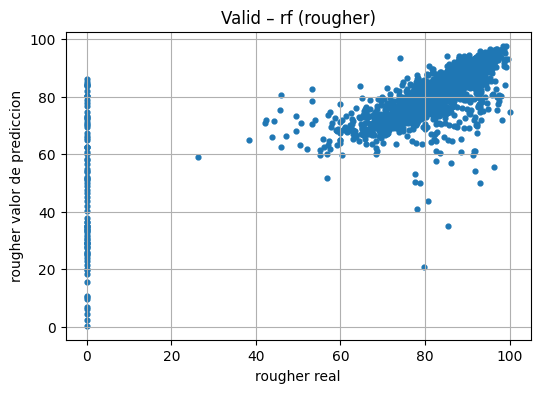

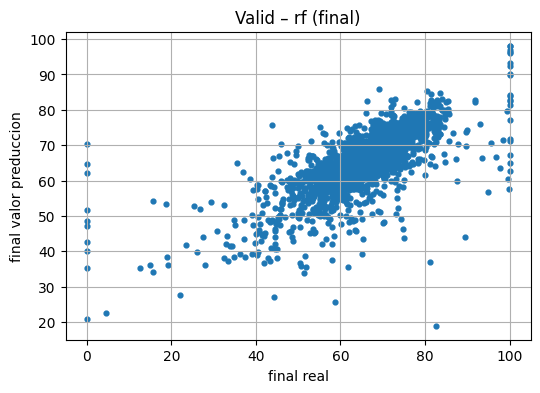

In [15]:
best_r, best_f = models_valid[best_kind]
pred_r_valid = pd.Series(best_r.predict(features_valid), index=target_valid_r.index)
pred_f_valid = pd.Series(best_f.predict(features_valid), index=target_valid_f.index)

plt.figure(figsize=(6,4))
plt.scatter(target_valid_r, pred_r_valid, s=12)
plt.xlabel("rougher real"); plt.ylabel("rougher valor de prediccion"); plt.title(f"Valid – {best_kind} (rougher)")
plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.scatter(target_valid_f, pred_f_valid, s=12)
plt.xlabel("final real"); plt.ylabel("final valor preduccion"); plt.title(f"Valid – {best_kind} (final)")
plt.grid(True); plt.show()

El modelo no es tan fiable con valores cercanos a cero en la recuperacion para rougher mientras que el final es mejor alienado a la convergencia lineal, esta dispersión nos da fiabildad.

<div class="alert alert-block alert-success">
<b>Comentario revisor</b> <a class="tocSkip"></a><br>
    
Excelente trabajo con el calculo de la de la evolución de la concentración de los materiales mediante un ciclo for que itera sobre cada metal y etapa. Además complementas con gráficas que se puedan vincular a los resultados que obtienes. 

In [16]:
best_r_full = get_model(best_kind)
best_f_full = get_model(best_kind)
best_r_full.fit(rec_train[features], rec_train[target_cols[0]])
best_f_full.fit(rec_train[features], rec_train[target_cols[1]])

preds_test = pd.DataFrame({
    "pred_rougher.output.recovery": best_r_full.predict(rec_test[features]),
    "pred_final.output.recovery":   best_f_full.predict(rec_test[features]),
}, index=rec_test.index)

print("\n[Predicciones test] Primeras 5 filas:")
print(preds_test.head().to_string())


[Predicciones test] Primeras 5 filas:
   pred_rougher.output.recovery  pred_final.output.recovery
0                     88.145520                   68.094624
1                     87.078713                   69.187147
2                     86.040058                   68.521882
3                     87.435905                   69.651609
4                     87.586316                   69.138587


De acuerdo al modelo, el 88% del oro queda justo despues de la flotacion mientras que el 69% queda tras pasar por los procesos de purificación.

In [17]:
def smape(target_true, target_pred):
    y = pd.Series(target_true).astype(float)
    yhat = pd.Series(target_pred).astype(float)
    denom = (y.abs() + yhat.abs()) / 2
    term = (y - yhat).abs() / denom.replace(0, np.nan)
    return float(term.fillna(0).mean() * 100)

In [18]:
smape_rougher = smape(target_valid_r, pred_r_valid)
smape_final   = smape(target_valid_f, pred_f_valid)
smape_compuesto = 0.25 * smape_rougher + 0.75 * smape_final
print(f"sMAPE(rougher) = {smape_rougher:.2f}%")
print(f"sMAPE(final)   = {smape_final:.2f}%")
print(f"sMAPE compuesto (25/75) = {smape_compuesto:.2f}%")

sMAPE(rougher) = 8.46%
sMAPE(final)   = 6.39%
sMAPE compuesto (25/75) = 6.91%


Conclusion:

El random forest logra un sMAPE final de 6.91% es solido ya que este valor indica que está muy cerca del promedio por ende es un valor muy positivo.

<div class="alert alert-block alert-danger">
<b>Comentario revisor</b> <a class="tocSkip"></a><br>

Solamente para terminar de complementar el análisis te recomiendo la implementación del escalado de datos. Aplicar técnicas como la normalización o estandarización mejora significativamente la estabilidad numérica de los modelos y garantiza que todas las variables contribuyan de manera equitativa al proceso de aprendizaje. Esto fortalece la interpretabilidad y el rendimiento del modelo.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo con el ajuste!
</div>